In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# Give colab access to google drive

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Load Peper image and plot it

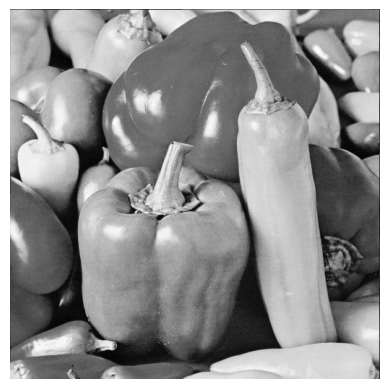

In [ ]:
# import packages
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# image path
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

# load image
img = sio.loadmat(work_path + 'Data/Peppers.mat')['peppers']

# plot image
plt.imshow(img,cmap='gray')
plt.axis('off');

# Perform 2D-DFT

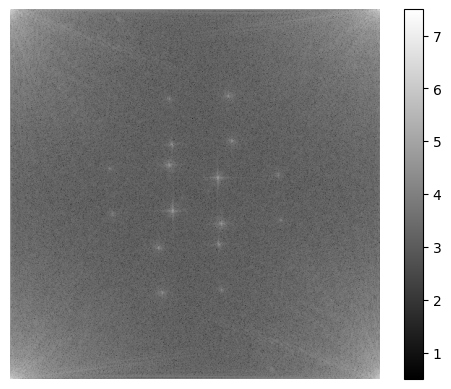

In [ ]:
# take 2D-DFT
img_dft = np.fft.fft2(img)

# The scale is not good due to strong components (e.g. the 0,0 DC component). Here we take logarithmic scale
im = plt.imshow(np.log10(np.abs(img_dft)),cmap='gray')
plt.axis('off')
plt.colorbar(im)

# Perform Inverse 2D-DFT

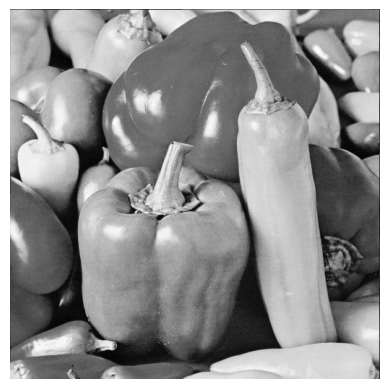

In [ ]:
# take 2D-iDFT
img_idft = np.fft.ifft2(img_dft)

plt.imshow(np.abs(img_idft),cmap='gray')
plt.axis('off');

# Load Dog Image

(np.float64(-0.5), np.float64(755.5), np.float64(1007.5), np.float64(-0.5))

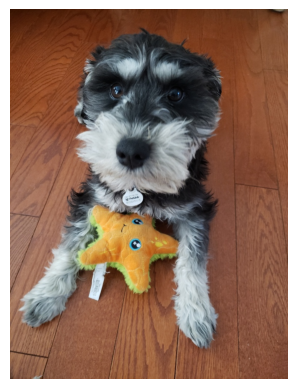

In [ ]:
from matplotlib import image
import numpy as np

# load image
img = image.imread(work_path + 'Data/Dog.jpg')
img = np.transpose(img, (0,1,2))

# plot image
import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis('off')

# Perform 2D-DFT on Dog Image

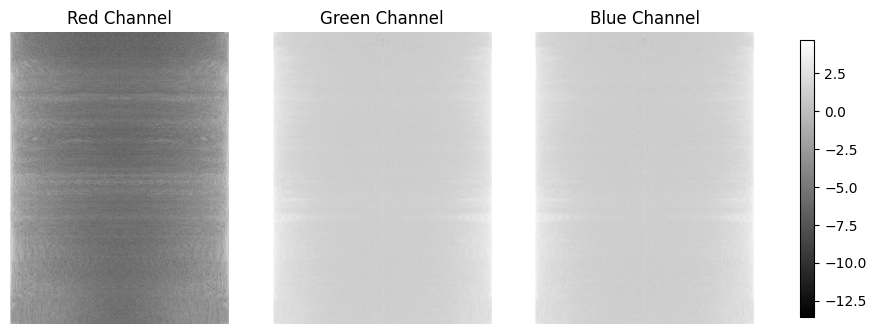

In [ ]:
from scipy.fftpack import dct

# take 2D-DFT
img_dft = np.fft.fft2(img)

fig, ax = plt.subplots(1, 3, figsize=(12, 8))

# red channel
im = ax[0].imshow(np.log10(np.abs(img_dft[:,:,0])),cmap='gray')
ax[0].set_title('Red Channel')
ax[0].axis('off')

# green channel
im = ax[1].imshow(np.log10(np.abs(img_dft[:,:,1])),cmap='gray')
ax[1].set_title('Green Channel')
ax[1].axis('off')

# blue channel
im = ax[2].imshow(np.log10(np.abs(img_dft[:,:,2])),cmap='gray')
ax[2].set_title('Blue Channel')
ax[2].axis('off')

fig.colorbar(im, ax=ax.ravel().tolist(), shrink = 0.45)

# Perform inverse 2D-DFT

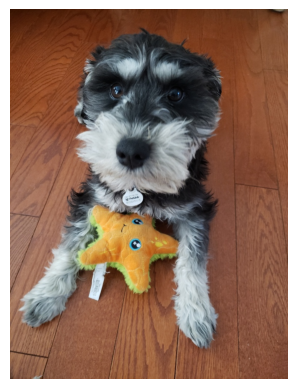

In [ ]:
import cv2

# take 2D-iDFT
img_idft = np.fft.ifft2(img_dft)

norm_image = cv2.normalize(np.abs(img_idft), None, alpha = 0, beta = 255, norm_type = cv2.NORM_MINMAX, dtype = cv2.CV_32F)

plt.figure()
im = plt.imshow(norm_image.astype(np.uint8))
plt.axis('off');